<a href="https://colab.research.google.com/github/Janardan-thapaliya/RAG/blob/main/Corrective_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain_community langchain_openai langchain_text_splitters langchain_core langgraph pypdf faiss-cpu python-dotenv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.1/500.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.6/330.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

In [ ]:
# load env vars
load_dotenv()

In [ ]:
# Data + Index
# -----------------------------
docs = (
    PyPDFLoader("/content/book1.pdf").load()
    + PyPDFLoader("/content/book2.pdf").load()
    + PyPDFLoader("/content/book3.pdf").load()
)

In [ ]:
# import os
# os.environ["OPENAI_API_KEY"] = ""
# os.environ["TAVILY_API_KEY"] = ""

In [ ]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [ ]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [ ]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:
# State
# -----------------------------
class State(TypedDict):
    question: str

    docs: List[Document]
    good_docs: List[Document]

    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_query: str

    web_docs: List[Document]

    answer: str

In [ ]:
# Retrieve
# -----------------------------
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [ ]:
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        # Keep any doc above LOWER_TH as "weakly relevant"
        if out.score > LOWER_TH:
            good.append(d)

    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }

In [ ]:
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:  # AMBIGUOUS
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [ ]:
# Query rewrite for web search
# -----------------------------
class WebQuery(BaseModel):
    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

# Web search node: uses web_query
# -----------------------------
tavily = TavilySearchResults(max_results=5)


def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    web_docs: List[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

/tmp/ipython-input-1935637364.py:31: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [ ]:
# Generate
# -----------------------------
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": out.content}

In [ ]:
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"

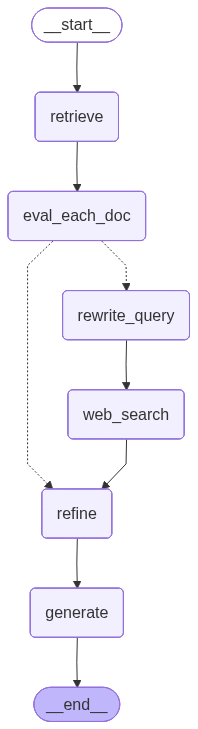

In [ ]:
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [ ]:
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": "Batch normalization vs layer normalization",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("WEB_QUERY:", res["web_query"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3.
WEB_QUERY: Batch normalization vs layer normalization

OUTPUT:
 Batch normalization (BN) normalizes the activations of a layer within a mini-batch during training by subtracting the mini-batch mean and dividing by the mini-batch standard deviation. It operates on the batch dimension and is effective in feed-forward networks and convolutional neural networks (CNNs) with large datasets.

Layer normalization (LN), on the other hand, normalizes the inputs across features for each layer independently of the batch size. It calculates the mean and standard deviation instance-wise, normalizing each feature using these statistics. LN is particularly useful for tasks with limited or varying batch sizes, such as recurrent neural networks (RNNs) and transformers.

In summary, BN is suitable for larger batch sizes and accelerates training by leveraging batch statistics, while LN is independent of batch size and is often more 

In [ ]:
res["answer"]

'Batch normalization (BN) normalizes the activations of a layer within a mini-batch during training by subtracting the mini-batch mean and dividing by the mini-batch standard deviation. It operates on the batch dimension and is effective in feed-forward networks and convolutional neural networks (CNNs) with large datasets.\n\nLayer normalization (LN), on the other hand, normalizes the inputs across features for each layer independently of the batch size. It calculates the mean and standard deviation instance-wise, normalizing each feature using these statistics. LN is particularly useful for tasks with limited or varying batch sizes, such as recurrent neural networks (RNNs) and transformers.\n\nIn summary, BN is suitable for larger batch sizes and accelerates training by leveraging batch statistics, while LN is independent of batch size and is often more effective for sequence data and tasks where batch sizes are limited.'

In [ ]:
res["docs"]

[Document(id='e041b7ac-1f8d-4aea-b8e0-b961678fc313', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2019-01-26T22:50:33+16:00', 'enhanced': 'By PDF Enhancer 3.5.6412/Unix', 'spdf': '1127', 'source': '/content/book2.pdf', 'total_pages': 801, 'page': 332, 'page_label': '333'}, page_content='Batchnormalization( ,)isoneofthemostexcitingrecentIoﬀeandSzegedy2015\ninnovationsinoptimizingdeepneuralnetworksanditisactuallynotanoptimization\nalgorithmatall.Instead,itisamethodofadaptivereparametrization,motivated\nbythediﬃcultyoftrainingverydeepmodels.\nVerydeepmodelsinvolvethecompositionofseveralfunctionsorlayers.The\ngradienttellshowtoupdateeachparameter,undertheassumptionthattheother\nlayersdonotchange.Inpractice,weupdateallofthelayerssimultaneously.\nWhenwemaketheupdate,unexpectedresultscanhappenbecausemanyfunctions\ncomposedtogetherarechangedsimultaneously,usingupdatesthatwerecomputed\nundertheassumptionthattheotherfunctionsremainconstant.Asa

In [ ]:
res["good_docs"]

[Document(id='0d7d0c9b-d0f7-4395-8eaa-8b7f75a06a50', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2019-01-26T22:50:33+16:00', 'enhanced': 'By PDF Enhancer 3.5.6412/Unix', 'spdf': '1127', 'source': '/content/book2.pdf', 'total_pages': 801, 'page': 333, 'page_label': '334'}, page_content='algorithmsareexpensiveandusuallyrequirenumerousapproximationsthatprevent\nthemfromtrulyaccountingforallsigniﬁcantsecond-orderinteractions.Building\nann-thorderoptimizationalgorithmforn>2thusseemshopeless.Whatcanwe\ndoinstead?\nBatchnormalizationprovidesanelegantwayofreparametrizingalmostanydeep\nnetwork.Thereparametrizationsigniﬁcantlyreducestheproblemofcoordinating\nupdatesacrossmanylayers.Batchnormalizationcanbeappliedtoanyinput\norhiddenlayerinanetwork.LetHbeaminibatchofactivationsofthelayer\ntonormalize,arrangedasadesignmatrix,withtheactivationsforeachexample\nappearinginarowofthematrix.Tonormalize,wereplaceitwithH\nH\ue030=H µ−\nσ , (8.35)\nwhere

In [ ]:
res["strips"]

['algorithmsareexpensiveandusuallyrequirenumerousapproximationsthatprevent themfromtrulyaccountingforallsigniﬁcantsecond-orderinteractions.Building ann-thorderoptimizationalgorithmforn>2thusseemshopeless.Whatcanwe doinstead?',
 'Batchnormalizationprovidesanelegantwayofreparametrizingalmostanydeep network.Thereparametrizationsigniﬁcantlyreducestheproblemofcoordinating updatesacrossmanylayers.Batchnormalizationcanbeappliedtoanyinput orhiddenlayerinanetwork.LetHbeaminibatchofactivationsofthelayer tonormalize,arrangedasadesignmatrix,withtheactivationsforeachexample appearinginarowofthematrix.Tonormalize,wereplaceitwithH H\ue030=H µ− σ , (8.35) whereµisavectorcontainingthemeanofeachunitandσisavectorcontaining thestandarddeviationofeachunit.Thearithmetichereisbasedonbroadcasting thevectorµandthevectorσtobeappliedtoeveryrowofthematrixH.Within 7 “Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift, ” S.',
 'Batch Normalization Although using He initiali

In [ ]:
res["kept_strips"]

['In a 2015 paper, 7 Sergey Ioffe and Christian Szegedy proposed a technique called Batch Normalization (BN) to address the vanishing/exploding gradients problems, and more generally the problem that the distribution of each layer’s inputs changes during training, as the parameters of the previous layers change (which they call the Internal Covariate Shift problem).',
 'Batch Normalisation (BN): Batch Normalization is a technique used to normalize the activations of a layer within a mini-batch during training.',
 'BN normalizes the activations by subtracting the mini-batch mean and dividing by the mini-batch standard deviation.',
 'In essence, BN acts on the batch dimension, hence the name “Batch Normalization.” 2.',
 'Despite its drawbacks, applying batch normalization still remains a valuable tool in the arsenal of neural network practitioners, offering tangible benefits in terms of training efficiency and performance.',
 'Layer normalization or layer norm presents an alternative app

In [ ]:
res["web_query"]

'Batch normalization vs layer normalization'

In [ ]:
res["web_docs"]

[Document(metadata={'url': 'https://medium.com/@prudhviraju.srivatsavaya/layer-normalisation-and-batch-normalisation-c315ffe9a84b', 'title': 'Layer Normalisation and Batch Normalisation - Medium'}, page_content='TITLE: Layer Normalisation and Batch Normalisation - Medium\nURL: https://medium.com/@prudhviraju.srivatsavaya/layer-normalisation-and-batch-normalisation-c315ffe9a84b\nCONTENT:\n1. Batch Normalisation (BN):\n\n Batch Normalization is a technique used to normalize the activations of a layer within a mini-batch during training.\n It is commonly applied to intermediate layers of a neural network to help stabilize training, reduce internal covariate shift, and improve the convergence of the model.\n BN normalizes the activations by subtracting the mini-batch mean and dividing by the mini-batch standard deviation. These operations are learnable through parameters (gamma and beta) to allow the model to adjust the normalization.\n In essence, BN acts on the batch dimension, hence the

In [ ]:
res["refined_context"]

"In a 2015 paper, 7 Sergey Ioffe and Christian Szegedy proposed a technique called Batch Normalization (BN) to address the vanishing/exploding gradients problems, and more generally the problem that the distribution of each layer’s inputs changes during training, as the parameters of the previous layers change (which they call the Internal Covariate Shift problem).\nBatch Normalisation (BN): Batch Normalization is a technique used to normalize the activations of a layer within a mini-batch during training.\nBN normalizes the activations by subtracting the mini-batch mean and dividing by the mini-batch standard deviation.\nIn essence, BN acts on the batch dimension, hence the name “Batch Normalization.” 2.\nDespite its drawbacks, applying batch normalization still remains a valuable tool in the arsenal of neural network practitioners, offering tangible benefits in terms of training efficiency and performance.\nLayer normalization or layer norm presents an alternative approach to batch n